# Statistics for Problem transformation experiments

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score

#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [ini_results_filepath, nnrti_results_filepath, nrti_results_filepath, pi_results_filepath]




#setting filepaths for the benchmarking datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [ini_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, pi_results_filepath_ml]


## Binary relevance with TabPFN predicts labels on par with state of the art

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (13,) and arg 1 with shape (12,).

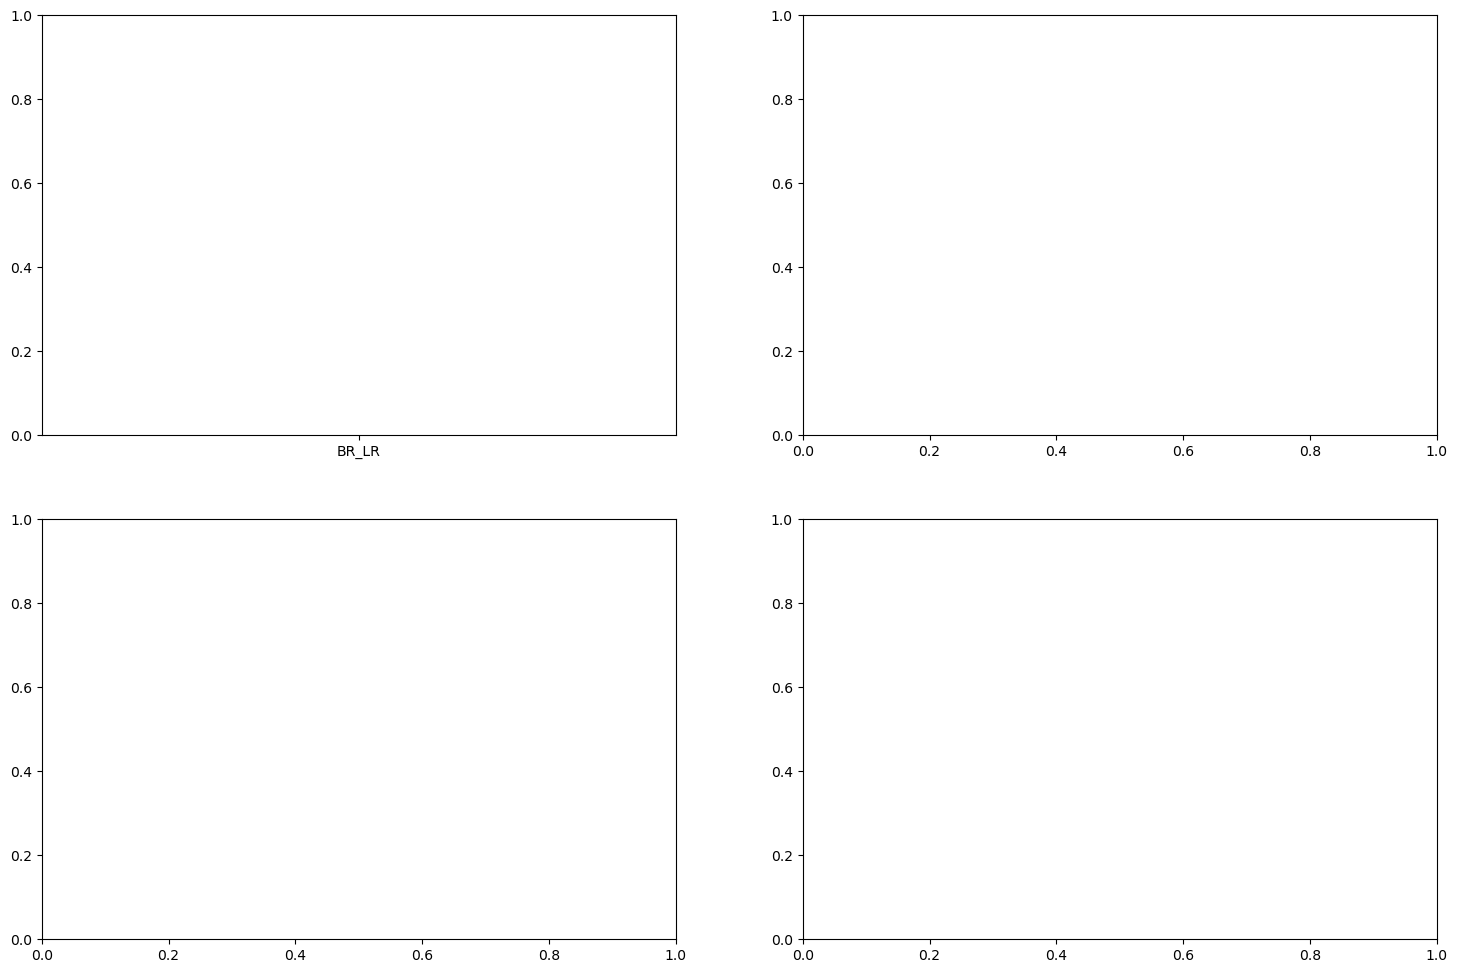

In [6]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

ending = "_5_fold.csv"

sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

[sub_accs_fold_mean[x].extend(tmp_sub_accs_fold_mean[x]) for x in sub_accs_fold_mean.keys()]
[sub_accs_fold_std[x].extend(tmp_sub_accs_fold_std[x]) for x in sub_accs_fold_std.keys()]


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN","BR TabICL wo NaN", "BR TabICL"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models  + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_exam_acc.png")


In [2]:
from sklearn.metrics import roc_auc_score
from result_handler import prc_auc_score


ending = "_5_fold.csv"


files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv","Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save_woNaN.csv"]

sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, prc_auc_score,metric_args={"multiclass":"ovr"}, drop_na=False)

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "BR TabPFN2"]

color = ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
plt.show()

#plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR.png")


In [ ]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest", "DELA"]

ending = "_probabilities.csv"

roc_auc_mean, roc_auc_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average":"macro"}, drop_na=True)

[roc_auc_mean[x].extend(tmp_roc_auc_mean[x]) for x in roc_auc_mean.keys()]
[roc_auc_std[x].extend(tmp_roc_auc_std[x]) for x in roc_auc_std.keys()]


df_sub_accs_groups_mean = pd.DataFrame(roc_auc_mean)
df_sub_accs_groups_std = pd.DataFrame(roc_auc_std)

sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

[sub_accs_fold_mean[x].extend(tmp_sub_accs_fold_mean[x]) for x in sub_accs_fold_mean.keys()]
[sub_accs_fold_std[x].extend(tmp_sub_accs_fold_std[x]) for x in sub_accs_fold_std.keys()]


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN","BR TabICL wo NaN", "BR TabICL"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:pink"] + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models  + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_exam_acc.png")
